## Binning and Binarization

Binning (also known as discretization) is the process of transforming continuous numerical variables into categorical ones (bins or intervals). This can help in handling non-linear relationships, reducing the impact of outliers, and improving model performance.

Binarization is a specific type of binning where continuous or categorical features are converted into binary (0 or 1) features based on a threshold or condition.

Let's start by loading the Titanic dataset and performing some initial data exploration.

In [4]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Titanic dataset
# The dataset can often be found directly from seaborn or fetched from a URL
# For simplicity, let's assume it's available or we can load it from seaborn's examples
try:
    titanic_df = sns.load_dataset('titanic')
except Exception:
    print("Could not load titanic dataset from seaborn. Trying a direct URL.")
    # Fallback if seaborn's dataset is not readily available or updated
    titanic_df = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')

# Display the first few rows and information about the dataset
print("Titanic Dataset Head:")
display(titanic_df.head())

print("\nTitanic Dataset Info:")
titanic_df.info()

Titanic Dataset Head:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True



Titanic Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


For our binning examples, let's focus on the `Age` and `Fare` columns, as they are continuous numerical variables suitable for discretization. We will also deal with missing values in `Age` for a cleaner demonstration.

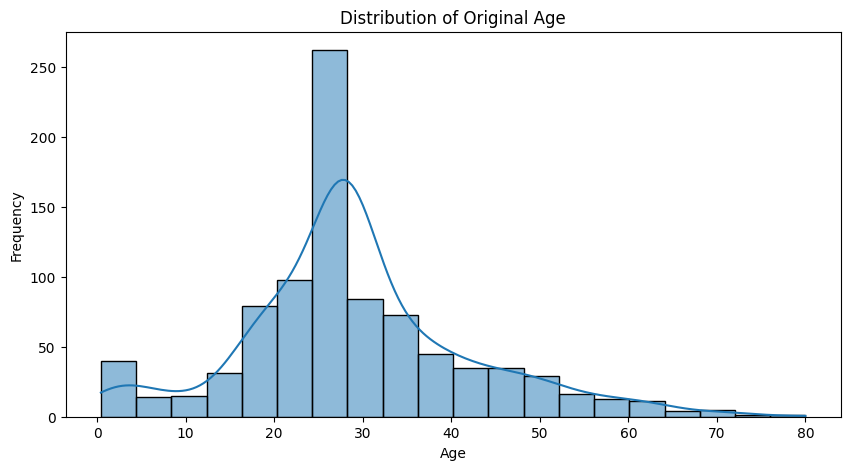

In [10]:
# Handle missing values in Age by filling with the median
titanic_df['age'] = titanic_df['age'].fillna(titanic_df['age'].median())

# Let's verify the distribution of the original Age column
plt.figure(figsize=(10, 5))
sns.histplot(titanic_df['age'], kde=True, bins=20)
plt.title('Distribution of Original Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

### Unsupervised Binning: Equal Width (Uniform) Binning

Equal width binning divides the range of the numerical feature into `n` bins of equal width. The width of each bin is determined by `(max_value - min_value) / n`.

Let's apply equal width binning to the `Age` column and visualize the new distribution.

Counts for Equal Width Bins (Age):


,count
Age_EqualWidth_Bins,
0,100
1,523
2,188
3,69
4,11


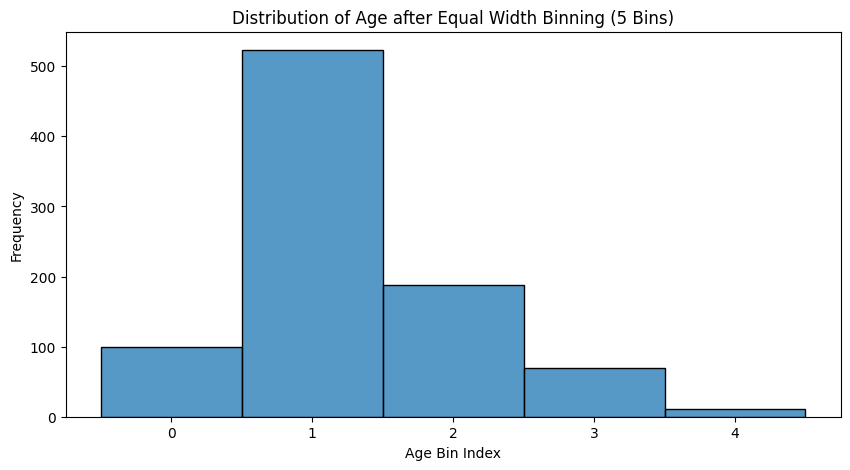

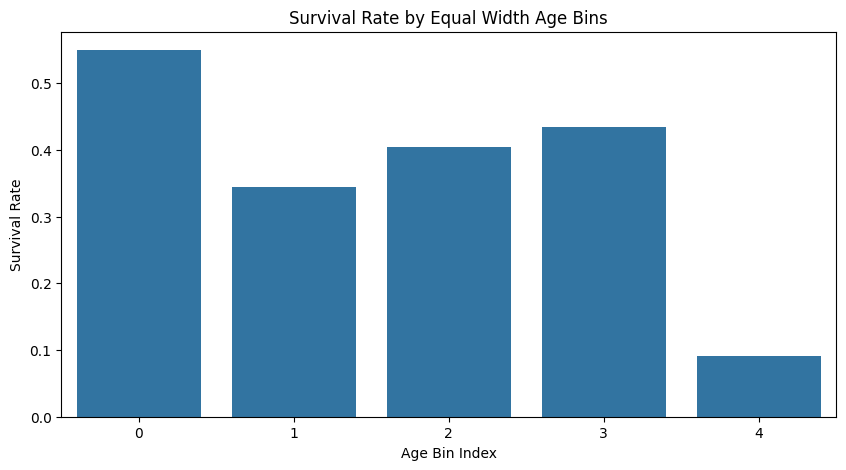

In [11]:
# Apply equal width binning to the 'Age' column
# Let's create 5 bins of equal width
titanic_df['Age_EqualWidth_Bins'] = pd.cut(titanic_df['age'], bins=5, labels=False, include_lowest=True)

print("Counts for Equal Width Bins (Age):")
display(titanic_df['Age_EqualWidth_Bins'].value_counts().sort_index())

# Visualize the distribution of the binned 'Age' column
plt.figure(figsize=(10, 5))
sns.histplot(titanic_df['Age_EqualWidth_Bins'], discrete=True, stat='count')
plt.title('Distribution of Age after Equal Width Binning (5 Bins)')
plt.xlabel('Age Bin Index')
plt.ylabel('Frequency')
plt.xticks(np.arange(5)) # Ensure all bin indices are shown on x-axis
plt.show()

# Also, let's see how the binned age relates to survival (a supervised aspect)
plt.figure(figsize=(10, 5))
sns.barplot(x='Age_EqualWidth_Bins', y='survived', data=titanic_df, errorbar=None)
plt.title('Survival Rate by Equal Width Age Bins')
plt.xlabel('Age Bin Index')
plt.ylabel('Survival Rate')
plt.show()

### Unsupervised Binning: Quantile (Equal Frequency) Binning

Quantile binning divides the numerical feature into `n` bins, where each bin contains approximately the same number of observations. This method is useful when the data distribution is skewed.

Let's apply quantile binning to the `Fare` column, which often has a skewed distribution, and visualize its effect.

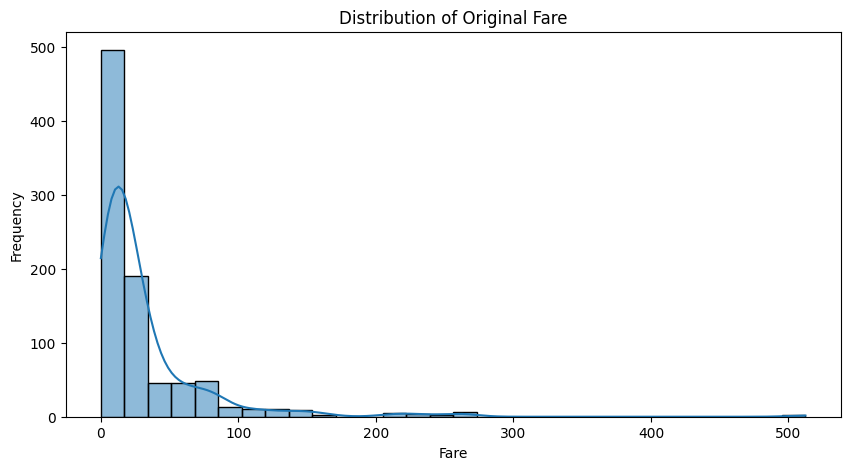

Counts for Quantile Bins (Fare):


,count
Fare_Quantile_Bins,
0,179
1,184
2,172
3,180
4,176


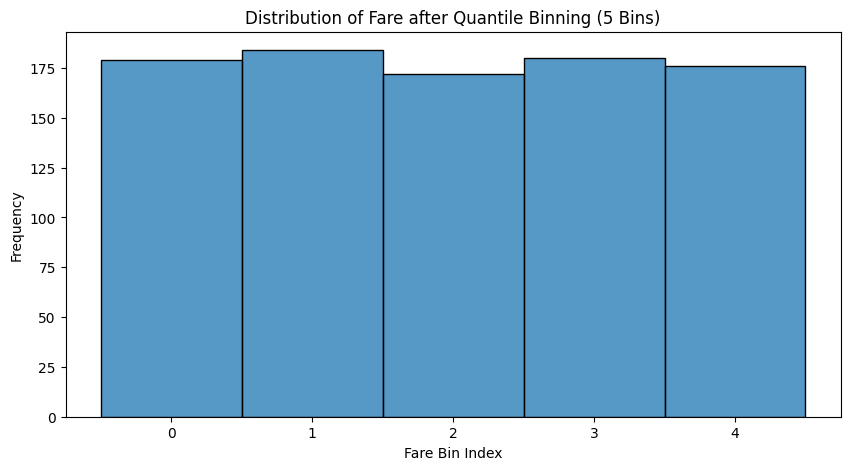

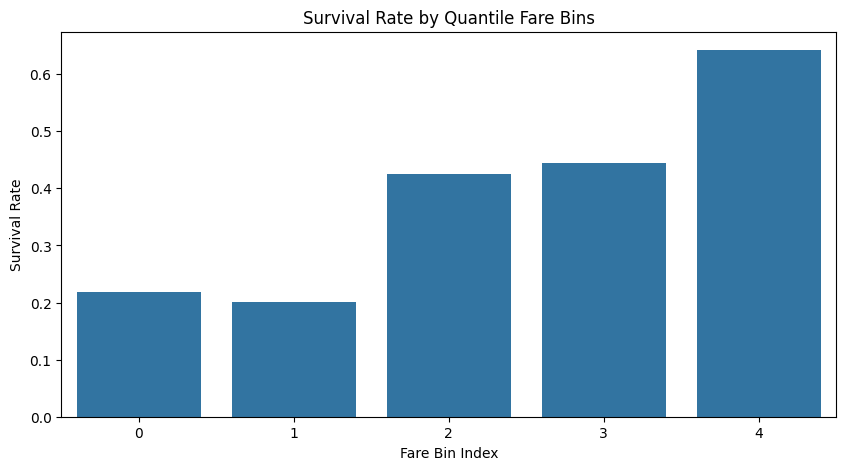

In [12]:
# Handle missing values in Fare by filling with the median (if any)
titanic_df['fare'] = titanic_df['fare'].fillna(titanic_df['fare'].median())

# Let's verify the distribution of the original Fare column
plt.figure(figsize=(10, 5))
sns.histplot(titanic_df['fare'], kde=True, bins=30)
plt.title('Distribution of Original Fare')
plt.xlabel('Fare')
plt.ylabel('Frequency')
plt.show()

# Apply quantile binning to the 'Fare' column
# Let's create 5 bins of equal frequency
titanic_df['Fare_Quantile_Bins'] = pd.qcut(titanic_df['fare'], q=5, labels=False, duplicates='drop')

print("Counts for Quantile Bins (Fare):")
display(titanic_df['Fare_Quantile_Bins'].value_counts().sort_index())

# Visualize the distribution of the binned 'Fare' column
plt.figure(figsize=(10, 5))
sns.histplot(titanic_df['Fare_Quantile_Bins'], discrete=True, stat='count')
plt.title('Distribution of Fare after Quantile Binning (5 Bins)')
plt.xlabel('Fare Bin Index')
plt.ylabel('Frequency')
plt.xticks(np.arange(titanic_df['Fare_Quantile_Bins'].nunique()))
plt.show()

# Visualize survival rate by Fare quantile bins
plt.figure(figsize=(10, 5))
sns.barplot(x='Fare_Quantile_Bins', y='survived', data=titanic_df, errorbar=None)
plt.title('Survival Rate by Quantile Fare Bins')
plt.xlabel('Fare Bin Index')
plt.ylabel('Survival Rate')
plt.show()

### Unsupervised Binning: K-Means Binning

K-Means binning uses the K-Means clustering algorithm to determine the bin boundaries. Instead of equal width or equal frequency, K-Means tries to partition data points into `k` clusters such that each data point belongs to the cluster with the nearest mean, serving as a prototype of the cluster. These cluster centers can then define the bins.

Let's apply K-Means binning to the `Fare` column and see how it differs from quantile binning.

Counts for K-Means Bins (Fare):


,count
Fare_KMeans_Bins,
0,716
1,122
2,33
3,17
4,3


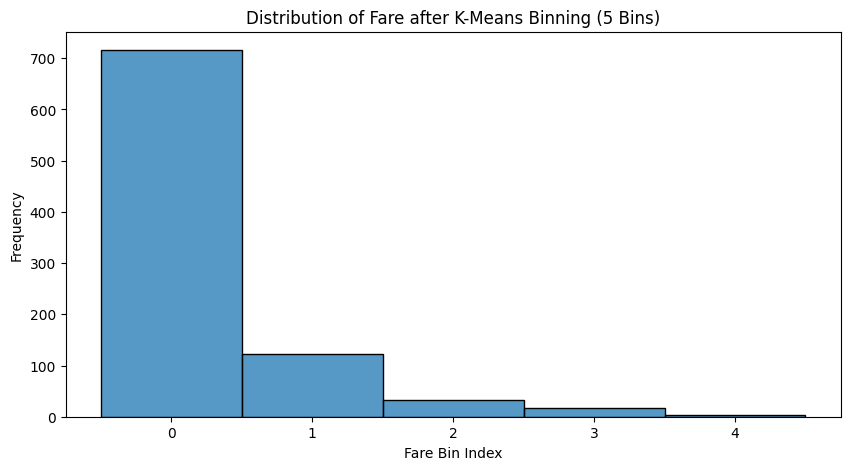

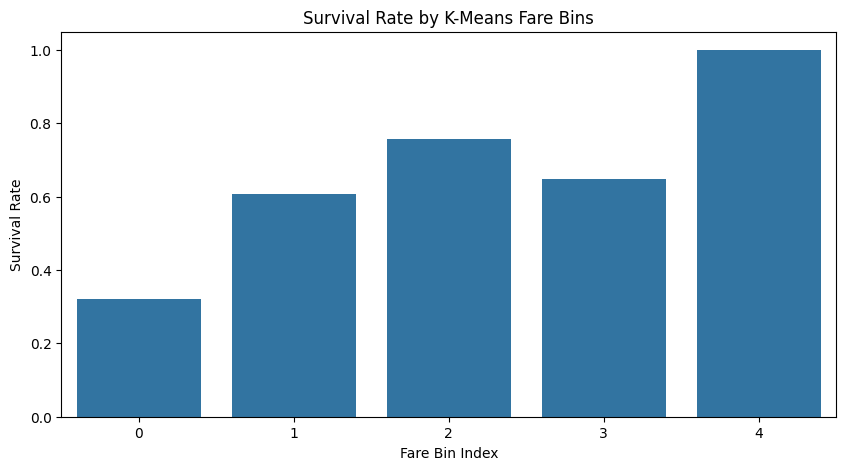

In [8]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Prepare the 'Fare' data for K-Means
# It's good practice to scale data before K-Means
fare_data = titanic_df[['fare']].values
scaler = StandardScaler()
fare_scaled = scaler.fit_transform(fare_data)

# Apply K-Means clustering
# Let's try to create 5 clusters (bins)
k = 5
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10) # n_init to suppress warning
titanic_df['Fare_KMeans_Bins'] = kmeans.fit_predict(fare_scaled)

# Sort the bin labels based on the cluster centers to ensure logical ordering
sorted_centers = np.sort(kmeans.cluster_centers_.flatten())
mapping = {old_label: new_label for new_label, old_label in enumerate(np.argsort(kmeans.cluster_centers_.flatten()))}
titanic_df['Fare_KMeans_Bins'] = titanic_df['Fare_KMeans_Bins'].map(mapping)

print("Counts for K-Means Bins (Fare):")
display(titanic_df['Fare_KMeans_Bins'].value_counts().sort_index())

# Visualize the distribution of the binned 'Fare' column
plt.figure(figsize=(10, 5))
sns.histplot(titanic_df['Fare_KMeans_Bins'], discrete=True, stat='count')
plt.title('Distribution of Fare after K-Means Binning (5 Bins)')
plt.xlabel('Fare Bin Index')
plt.ylabel('Frequency')
plt.xticks(np.arange(k)) # Ensure all bin indices are shown on x-axis
plt.show()

# Visualize survival rate by Fare K-Means bins
plt.figure(figsize=(10, 5))
sns.barplot(x='Fare_KMeans_Bins', y='survived', data=titanic_df, errorbar=None)
plt.title('Survival Rate by K-Means Fare Bins')
plt.xlabel('Fare Bin Index')
plt.ylabel('Survival Rate')
plt.show()

### Supervised Binning: Decision Tree Binning

Decision tree binning is a supervised method where a decision tree algorithm is used to find optimal cut points that maximize the predictive power of the binned variable with respect to a target variable. This is particularly useful for feature engineering in predictive modeling.

Let's apply decision tree binning to the `Age` column to predict `Survived`.

Decision Tree learned cut points for Age: [np.float64(0.9600000083446503), np.float64(2.5), np.float64(6.5), np.float64(28.75), np.float64(63.5), np.float64(77.0)]
Counts for Decision Tree Bins (Age):


,count
Age_DecisionTree_Bins,
0,7
1,17
2,23
3,494
4,337
5,12
6,1


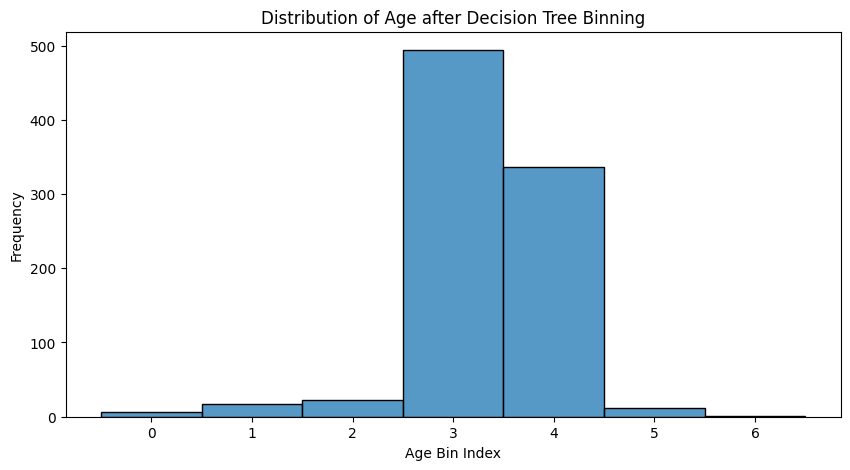

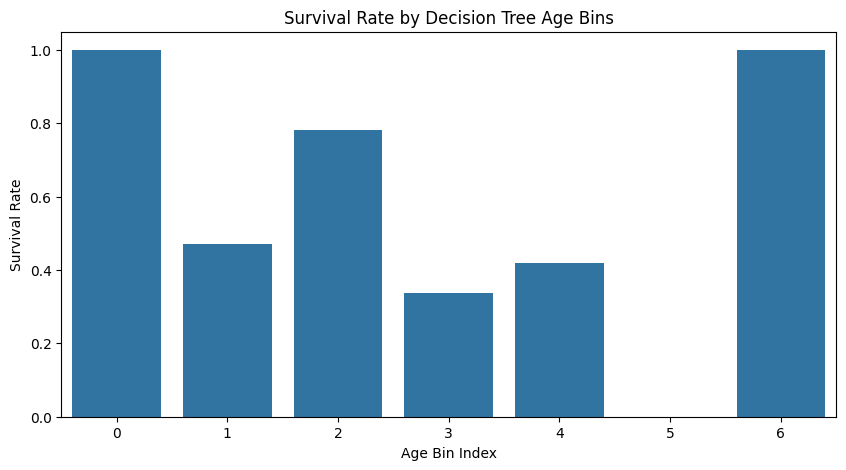

In [9]:
from sklearn.tree import DecisionTreeClassifier, export_text

# Drop rows with NaN in 'age' or 'survived' for this specific task if any remain
# (though we filled 'age' earlier, just a precaution)
temp_df = titanic_df[['age', 'survived']].dropna().copy()

# Define features (X) and target (y)
X = temp_df[['age']]
y = temp_df['survived']

# Initialize a Decision Tree Classifier
# We'll limit the depth to create a few bins
tree_binning = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_binning.fit(X, y)

# Extract bin boundaries (cut points) from the decision tree
# This requires inspecting the tree structure
feature_name = 'age'
def get_cut_points(tree, feature_name):
    left = tree.tree_.children_left
    right = tree.tree_.children_right
    thresholds = tree.tree_.threshold
    features = tree.tree_.feature

    cut_points = set()
    for i, f in enumerate(features):
        if f == X.columns.get_loc(feature_name) and thresholds[i] != -2:
            cut_points.add(thresholds[i])
    return sorted(list(cut_points))

cut_points = get_cut_points(tree_binning, 'age')
print(f"Decision Tree learned cut points for Age: {cut_points}")

# Add the min and max age to the cut points to define the full range of bins
min_age = titanic_df['age'].min()
max_age = titanic_df['age'].max()
full_cut_points = [min_age] + cut_points + [max_age]

# Ensure cut_points are unique and sorted
full_cut_points = sorted(list(set(full_cut_points)))

# Apply the bins to the original dataframe
titanic_df['Age_DecisionTree_Bins'] = pd.cut(titanic_df['age'], bins=full_cut_points, labels=False, include_lowest=True)

print("Counts for Decision Tree Bins (Age):")
display(titanic_df['Age_DecisionTree_Bins'].value_counts().sort_index())

# Visualize the distribution of the binned 'Age' column
plt.figure(figsize=(10, 5))
sns.histplot(titanic_df['Age_DecisionTree_Bins'], discrete=True, stat='count')
plt.title('Distribution of Age after Decision Tree Binning')
plt.xlabel('Age Bin Index')
plt.ylabel('Frequency')
plt.xticks(np.arange(titanic_df['Age_DecisionTree_Bins'].nunique()))
plt.show()

# Visualize survival rate by Decision Tree Age bins
plt.figure(figsize=(10, 5))
sns.barplot(x='Age_DecisionTree_Bins', y='survived', data=titanic_df, errorbar=None)
plt.title('Survival Rate by Decision Tree Age Bins')
plt.xlabel('Age Bin Index')
plt.ylabel('Survival Rate')
plt.show()

### Binarization

Binarization is the process of converting numerical or categorical features into binary features (0 or 1). This is typically done by setting a threshold: values above the threshold become 1, and values at or below the threshold become 0. It can be useful for simplifying models, handling non-linear relationships, or as a form of feature engineering.

Let's apply binarization to the `Fare` column. We can choose a threshold, for example, the median fare, to create a binary feature indicating whether a passenger paid above or below the median fare.

Median Fare for Binarization Threshold: 14.4542
Counts for Binarized Fare (Threshold at Median):


,count
Fare_Binarized,
0.0,447
1.0,444


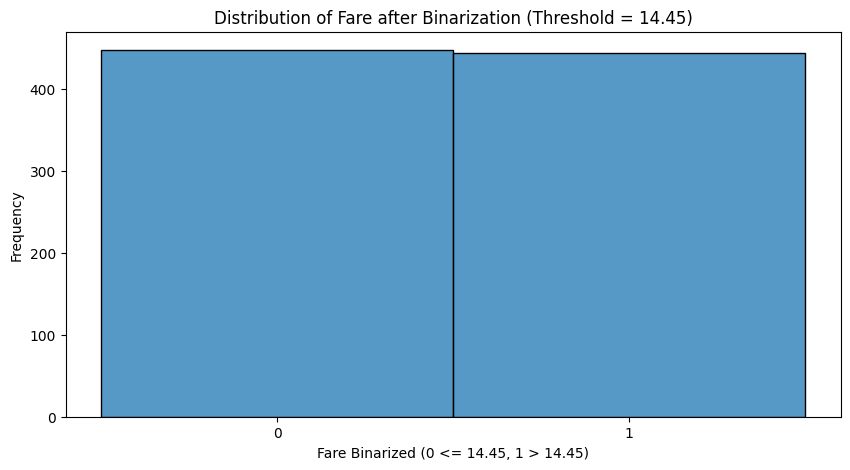

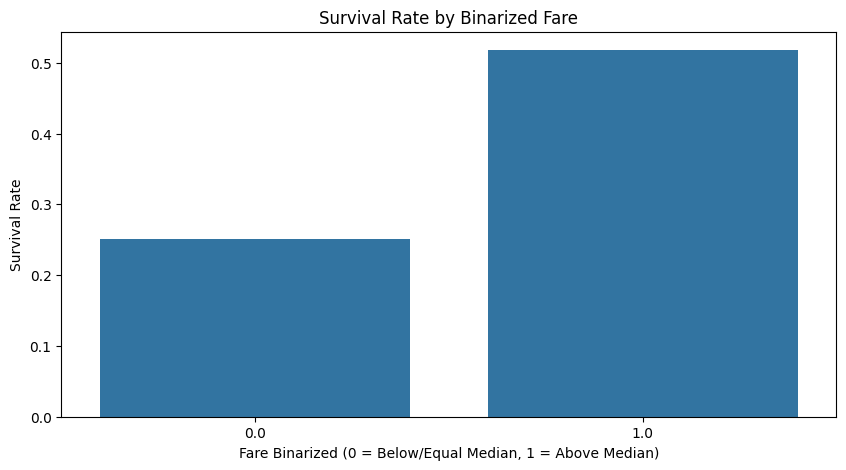

In [13]:
from sklearn.preprocessing import Binarizer

# Choose a threshold for binarization. Let's use the median fare.
fare_median = titanic_df['fare'].median()
print(f"Median Fare for Binarization Threshold: {fare_median}")

# Apply Binarization
# Create a new column 'Fare_Binarized' where 1 indicates fare > median, 0 otherwise
binarizer = Binarizer(threshold=fare_median)
titanic_df['Fare_Binarized'] = binarizer.fit_transform(titanic_df[['fare']])

print("Counts for Binarized Fare (Threshold at Median):")
display(titanic_df['Fare_Binarized'].value_counts().sort_index())

# Visualize the distribution of the binarized 'Fare' column
plt.figure(figsize=(10, 5))
sns.histplot(titanic_df['Fare_Binarized'], discrete=True, stat='count')
plt.title(f'Distribution of Fare after Binarization (Threshold = {fare_median:.2f})')
plt.xlabel(f'Fare Binarized (0 <= {fare_median:.2f}, 1 > {fare_median:.2f})')
plt.ylabel('Frequency')
plt.xticks([0, 1])
plt.show()

# Visualize survival rate by Binarized Fare
plt.figure(figsize=(10, 5))
sns.barplot(x='Fare_Binarized', y='survived', data=titanic_df, errorbar=None)
plt.title('Survival Rate by Binarized Fare')
plt.xlabel('Fare Binarized (0 = Below/Equal Median, 1 = Above Median)')
plt.ylabel('Survival Rate')
plt.show()

### Summary of Binning and Binarization

We have explored various methods of binning and binarization on the Titanic dataset:

1.  **Equal Width (Uniform) Binning (Unsupervised):** Divided the `Age` column into bins of equal range. Simple but can lead to bins with very few or many observations if data is skewed.
2.  **Quantile (Equal Frequency) Binning (Unsupervised):** Divided the `Fare` column into bins, each containing roughly the same number of observations. Useful for skewed data.
3.  **K-Means Binning (Unsupervised):** Used K-Means clustering on the `Fare` column to create bins based on data density, aiming to group similar values together.
4.  **Decision Tree Binning (Supervised):** Applied a Decision Tree to the `Age` column (with `Survived` as target) to find optimal cut-off points that maximize the predictive power of the bins.
5.  **Binarization:** Transformed the `Fare` column into a binary feature (0 or 1) based on a median threshold.

Each method has its strengths and weaknesses, and the choice depends on the data distribution, the specific problem, and the desired outcome (e.g., interpretability, model performance).

Feel free to ask if you want to explore any of these methods further, try different parameters, or discuss other binning strategies!